In [17]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
    
    

from src.config import PROCESSED_DATA_DIR
from src.utils.plots import save_figure, style_plot, create_figure, add_bar_labels, add_source, YOUTUBE_RED, save_table, interpret_eta_squared, DARK_RED
import pandas as pd


Saved: /Users/pro2020/projects/python/social-media-algorithm-analysis/outputs/q1/category-distribution.png


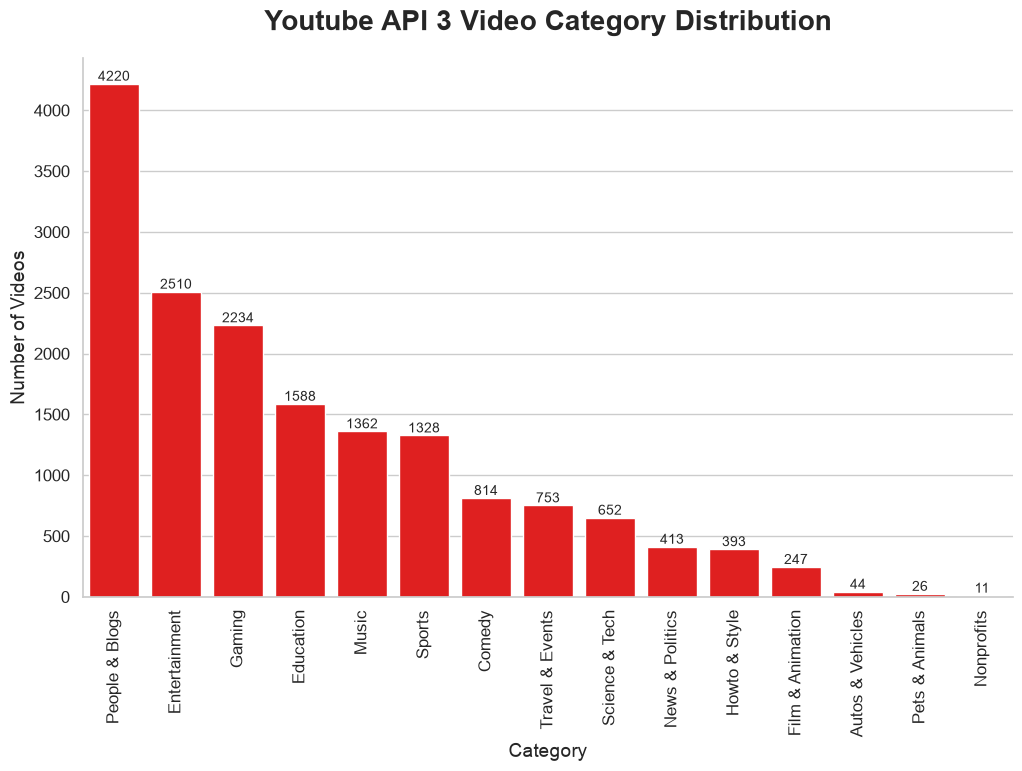

<Figure size 640x480 with 0 Axes>

In [3]:
df = pd.read_csv(PROCESSED_DATA_DIR / "youtube_clean.csv")


# category distribution
category_counts = (
    df["category_name"]
    .value_counts()
    .sort_values(ascending=False)
)


fig, ax = create_figure()
sns.barplot(
    x=category_counts.index,
    y=category_counts.values,
    ax=ax,
    color=YOUTUBE_RED
)
ax.tick_params(axis="x", rotation=90)

style_plot(ax=ax, xlabel='Category', ylabel='Number of Videos', title="Youtube API 3 Video Category Distribution")
add_bar_labels(ax)
save_figure(fig=fig,  filename='q1/category-distribution.png')
plt.show()
plt.clf()



In [4]:
# category performance
category_summary = (
    df.groupby("category_name")
    .agg(
        videos=("video_id", "count"),
        mean_views=("views", "mean"),
        median_views=("views", "median"),
        mean_likes=("likes", "mean"),
        median_likes=("likes", "median"),
        mean_comments=("comments", "mean"),
        median_comments=("comments", "median"),
        mean_engagement=("engagement_rate", "mean"),
        median_engagement=("engagement_rate", "median")
    )
    .sort_values("mean_engagement", ascending=False)
)


category_summary

,videos,mean_views,median_views,mean_likes,median_likes,mean_comments,median_comments,mean_engagement,median_engagement
category_name,,,,,,,,,
News & Politics,413,4.183672e+05,23957.0,6370.046005,367.0,461.530266,29.0,0.041460,0.017198
Pets & Animals,26,1.914742e+07,1534872.0,419442.384615,28866.5,1944.307692,231.5,0.039870,0.023471
Gaming,2234,2.536652e+06,273528.5,49017.376902,6337.0,1497.430170,345.0,0.034870,0.027713
Science & Tech,652,6.892760e+06,605885.0,166044.845092,14011.0,2033.473926,412.0,0.030253,0.026510
Howto & Style,393,2.274855e+07,647229.0,307372.239186,10481.0,1255.513995,152.0,0.028282,0.016891
Nonprofits,11,4.201137e+06,106031.0,60669.000000,4575.0,238.818182,34.0,0.026984,0.016930
People & Blogs,4220,6.607953e+06,255042.0,105563.412085,3478.5,928.853555,43.0,0.026616,0.017725
Education,1588,2.009370e+07,277922.5,74226.457179,3747.0,992.163098,33.0,0.024915,0.018817
Autos & Vehicles,44,6.805236e+06,52300.5,58653.227273,834.5,513.431818,28.5,0.024576,0.018669


Saved: /Users/pro2020/projects/python/social-media-algorithm-analysis/outputs/q1/mean_engagement_by_category.png


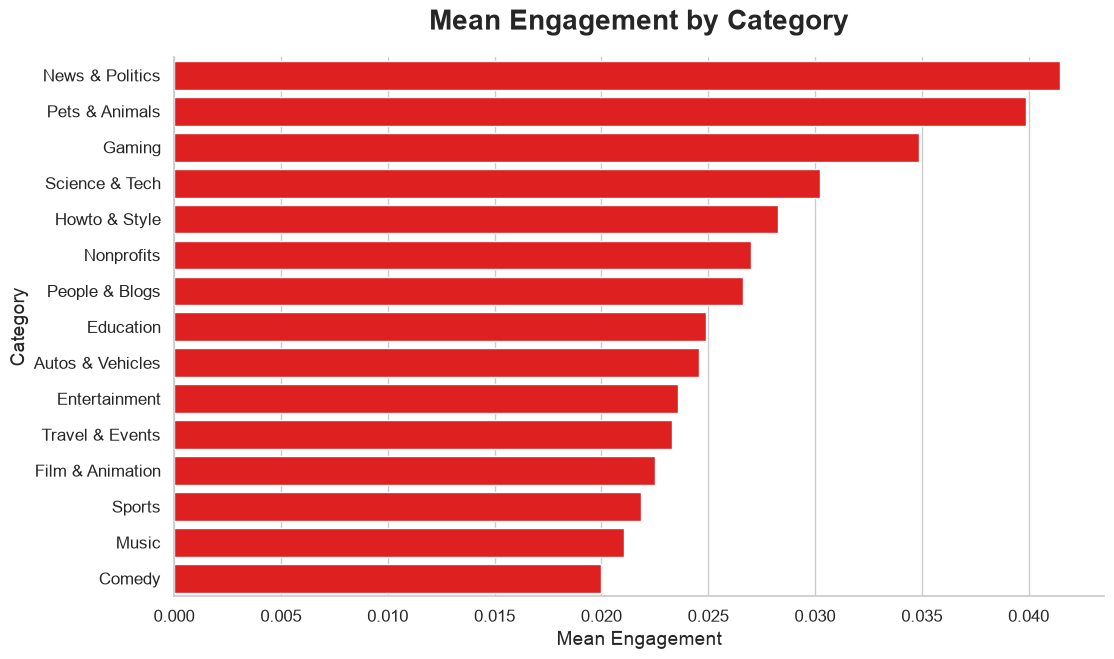

<Figure size 640x480 with 0 Axes>

In [5]:

fig, ax = create_figure()
sns.barplot(
    data=category_summary,
    x="mean_engagement",
    y="category_name",
    color=YOUTUBE_RED
)

style_plot(ax=ax, xlabel='Mean Engagement', ylabel='Category', title="Mean Engagement by Category")
save_figure(fig=fig, filename='q1/mean_engagement_by_category.png')

plt.show()
plt.clf()

In [6]:

metrics = (
    df.groupby("category_name")
    .agg({
        "likes":"mean",
        "comments":"mean",
        "engagement_rate":"mean",
        "views":"mean"
    })
)

metrics.idxmax()

likes                        Music
comments                     Music
engagement_rate    News & Politics
views                        Music
dtype: str

Saved: /Users/pro2020/projects/python/social-media-algorithm-analysis/outputs/q1/engagement_rate_by_category.png


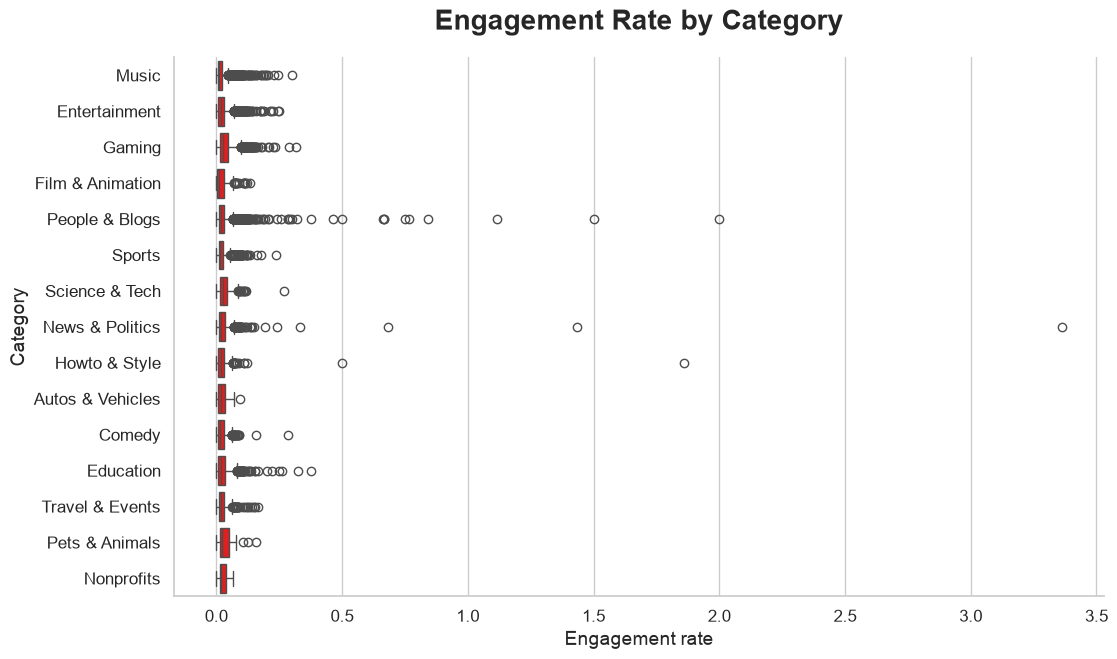

<Figure size 640x480 with 0 Axes>

In [7]:

fig, ax = create_figure()
sns.boxplot(
    data=df,
    x="engagement_rate",
    y="category_name",
    color=YOUTUBE_RED
)

style_plot(ax=ax, ylabel='Category', xlabel="Engagement rate", title="Engagement Rate by Category")
save_figure(fig=fig, filename='q1/engagement_rate_by_category.png')

plt.show()
plt.clf()

In [8]:
# ANOVA
from scipy.stats import f_oneway

# Null Hypothesis: there is no relationship between category and its engagement rate

groups = [
    group["engagement_rate"].values
    for _, group in df.groupby("category_name")
]

F, p = f_oneway(*groups)

print(f"F Statistic : {F:.3f}")
print(f"P-value     : {p:.5f}")

print(f"There is statistically significant evidence that mean engagement rates differ across YouTube content categories (ANOVA, F = {F:.3f}, p < .{p:.5f}).")

F Statistic : 12.266
P-value     : 0.00000
There is statistically significant evidence that mean engagement rates differ across YouTube content categories (ANOVA, F = 12.266, p < .0.00000).


In [9]:
# Turkey HSD
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df["engagement_rate"],
    groups=df["category_name"],
    alpha=0.05
)


results = pd.DataFrame(
    tukey.summary().data[1:],
    columns=tukey.summary().data[0]
)
significant = results[results["reject"] == True]
significant.sort_values("p-adj").head(20)

results.head()
save_table(
    results,
    "q1/tukey_results.csv"
)


/Users/pro2020/projects/python/social-media-algorithm-analysis/social_media_analyis_venv/lib/python3.13/site-packages/scipy/integrate/_quadpack_py.py:1286: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


Saved: /Users/pro2020/projects/python/social-media-algorithm-analysis/outputs/q1/tukey_results.csv


In [12]:

# ETA Squared
import statsmodels.api as sm
from statsmodels.formula.api import ols

model = ols(
    "engagement_rate ~ C(category_name)",
    data=df
).fit()

anova_table = sm.stats.anova_lm(
    model,
    typ=2
)

anova_table["eta_sq"] = (
    anova_table["sum_sq"] /
    anova_table["sum_sq"].sum()
)


eta = anova_table.loc["C(category_name)", "eta_sq"]
interpret_eta_squared(eta)

Effect Size (Eta Squared)
Eta Squared : 0.0103
Magnitude   : Small effect

Interpretation: Approximately 1.03% of the variation in engagement rate is explained by video category.
The remaining 98.97% of the variation is attributable to other factors not captured by category.


In [ ]:
# ANOVA AND ETA with log values
from scipy.stats import f_oneway

df.head()




# Null Hypothesis: there is no relationship between category and its engagement rate

groups = [
    group["engagement_rate"].values
    for _, group in df.groupby("category_name")
]

F, p = f_oneway(*groups)

print(f"F Statistic : {F:.3f}")
print(f"P-value     : {p:.5f}")

print(f"There is statistically significant evidence that mean engagement rates differ across YouTube content categories (ANOVA, F = {F:.3f}, p < .{p:.5f}).")

,video_id,title,description,channel_id,channel_title,published_at,category_id,tags,views,likes,...,hour,day_of_week,duration_seconds,duration_minutes,is_short,duration_group,is_viral,tag_count,has_tags,category_name
0,Q7IFjVUUb_E,"Stray Kids ""RUN IT"" M/V","Stray Kids(스트레이 키즈) ""RUN IT"" M/V\n\nListen to ...",UCaO6TYtlC8U5ttz62hTrZgg,JYP Entertainment,2026-06-24 04:00:01+00:00,10,"['JYP Entertainment', 'JYP', 'Stray Kids', '스트...",16971103,1123903,...,4,2,229,3.82,0,1-5 mins,1,49,True,Music
1,ynR3e3R7NjE,Spider-Man Brand New Day NEW FOOTAGE Breakdown...,Spider-Man Brand New Day Easter Eggs we missed...,UC7yRILFFJ2QZCykymr8LPwA,New Rockstars,2026-06-24 19:25:22+00:00,24,"['new rockstars', 'new rockstars youtube', 'yo...",403469,12452,...,19,2,866,14.43,0,5-15 mins,0,10,True,Entertainment
2,U-JyUSsROC0,Meccha Chameleon - Next Level Spots in Call of...,Outro Song: https://www.youtube.com/watch?v=qK...,UCKqH_9mk1waLgBiL2vT5b9g,VanossGaming,2026-06-25 01:48:24+00:00,20,"['Funny Moments', 'Montage video games', 'gami...",1227933,55197,...,1,3,2130,35.50,0,15-60 mins,0,16,True,Gaming
3,ic2A-IAGMcE,MYKE TOWERS || BZRP Music Sessions #42/66,#Bizarrap #MykeTowers \n\nMYKE TOWERS || BZRP ...,UCmS75G-98QihSusY7NfCZtw,Bizarrap,2026-06-25 00:00:12+00:00,24,[],4022004,404342,...,0,3,395,6.58,0,5-15 mins,0,0,False,Entertainment
4,Ho10_4IX1jE,Practical Magic 2 | Official Trailer,It's the season of the witch. #PracticalMagic2...,UCjmJDM5pRKbUlVIzDYYWb6g,Warner Bros.,2026-06-24 16:00:38+00:00,1,"['2026', 'Coming Soon', 'Dianne West', 'Fantas...",6061643,13240,...,16,2,162,2.70,0,1-5 mins,0,20,True,Film & Animation


       category_name          Statistic  Engagement Rate
0    News & Politics    mean_engagement         0.041460
1     Pets & Animals    mean_engagement         0.039870
2             Gaming    mean_engagement         0.034870
3     Science & Tech    mean_engagement         0.030253
4      Howto & Style    mean_engagement         0.028282
5         Nonprofits    mean_engagement         0.026984
6     People & Blogs    mean_engagement         0.026616
7          Education    mean_engagement         0.024915
8   Autos & Vehicles    mean_engagement         0.024576
9      Entertainment    mean_engagement         0.023580
10   Travel & Events    mean_engagement         0.023316
11  Film & Animation    mean_engagement         0.022515
12            Sports    mean_engagement         0.021871
13             Music    mean_engagement         0.021072
14            Comedy    mean_engagement         0.019965
15   News & Politics  median_engagement         0.017198
16    Pets & Animals  median_en

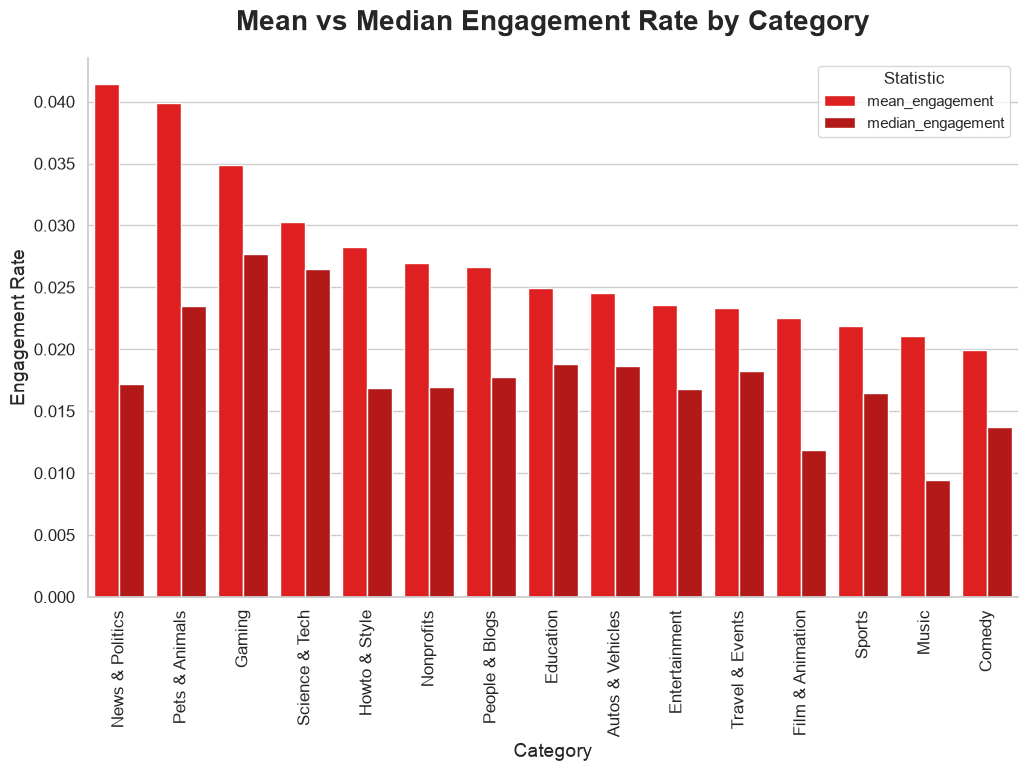

<Figure size 640x480 with 0 Axes>

In [ ]:
# Are categories consistently engaging, or are their averages inflated by a few viral videos?
engagement_summary = (
    df.groupby("category_name")
      .agg(
          mean_engagement=("engagement_rate", "mean"),
          median_engagement=("engagement_rate", "median")
      )
      .sort_values("mean_engagement", ascending=False)
)

plot_df = (
    engagement_summary
    .reset_index()
    .melt(
        id_vars="category_name",
        value_vars=["mean_engagement", "median_engagement"],
        var_name="Statistic",
        value_name="Engagement Rate"
    )
)



fig, ax = create_figure()

sns.barplot(
    data=plot_df,
    x="category_name",
    y="Engagement Rate",
    hue="Statistic",
    palette=[YOUTUBE_RED, DARK_RED],
    ax=ax
)

ax.tick_params(axis="x", rotation=90)

style_plot(
    ax,
    title="Mean vs Median Engagement Rate by Category",
    xlabel="Category",
    ylabel="Engagement Rate"
)

save_figure(fig, "q1/mean_vs_median_engagement.png")

plt.show()
plt.clf()